<a href="https://colab.research.google.com/github/MridulBenBist/AppliedML_Matlab_healthcare/blob/main/Copy_of_Example_Imagenette_Transformer_SVD_Oct10_2025_forMridul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# October 2025, example tutorial code with a small image set (from Imagenette) for SVD on vision transformer query-key self-attention
# computing the cosine similarity, and projecting images onto example top SVD components of a given layer and attention head.
# Based on X Pan, A Philip, Z Xie, O Schwartz (2024). Dissecting Query-Key Interaction in Vision Transformers. Advances in Neural Information Processing Systems 37 (NeurIPS 2024).
# Some of the transformer code based on Xu Pan's code https://github.com/schwartz-cnl/DissectingViT
# Some of the functions for reading images and displaying projections, written with input from ChatGPT-o3-mini-high and adjusted by OS

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import sys
import os



In [ ]:
# Transformer models
#######################
!pip install fastai transformers --quiet

import torch
#from transformers import ViTModel, ViTFeatureExtractor
from transformers import ViTModel, ViTImageProcessor
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from fastai.vision.all import untar_data, URLs

# Load the pretrained transformer model
# ------------------------------------------------------------
# Toggle the model, currently ViT and Dino
#model = ViTModel.from_pretrained("google/vit-base-patch16-224")
#feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
#model.eval()  # Set to evaluation mode

# DINO
model = ViTModel.from_pretrained("facebook/dino-vitb16",
                                 ignore_mismatched_sizes=True)
#feature_extractor = ViTFeatureExtractor.from_pretrained("facebook/dino-vitb16")
feature_extractor = ViTImageProcessor.from_pretrained("facebook/dino-vitb16")
model.eval()

# Choose the specific layer and head indices
layer_index = 9
head_index = 0

# Access the layer
vit_layer = model.encoder.layer[layer_index]

# Access the self-attention module.
# Note: For ViTModel, the attention module is typically nested as below.
self_attn = vit_layer.attention.attention


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/dino-vitb16
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [ ]:
# based on Xu Pan's code
import numpy as np
import os
import multiprocessing
import time
import torch
import matplotlib.pyplot as plt

class HuggingFaceUtils:
    """Collection of tools to perform spectral analysis and SVD on Transformer parameters"""

    def __init__(self, model):
        """
        Here, "model" should be a PyTorch HuggingFace model. This step exists to keep parameters on the CPU
        for multiprocessing over all available cores.
        """
        self.layer_list = [(name, param.to(torch.device('cpu'))) for name,param in model.named_parameters()]

    def block_diagonalize(self, A):
        """Take skew symmetric matrix and put in QSQ^T as presented in https://en.wikipedia.org/wiki/Skew-symmetric_matrix"""
        # A must be a antisymmetric (or skew symmetric) matrix
        assert np.array_equal(A, -A.T)

        d = A.shape[0]

        eigenvalues, eigenvectors = np.linalg.eig(A)
        imageigenvalues = np.imag(eigenvalues)
        realeigenvectors=np.real(eigenvectors)
        imageigenvectors=np.imag(eigenvectors)

        block_diag = np.zeros((d,d))
        V = []

        if d%2==0: # even dimention is an easy case
            for i in range(int(d/2)):
                block_diag[2*i,2*i+1]= imageigenvalues[2*i]
                block_diag[2*i+1,2*i]= imageigenvalues[2*i+1]
                V.append(realeigenvectors[:,2*i]*np.sqrt(2)) # scale V to be orthonormal, though not sure why it is not without scaling...
                V.append(imageigenvectors[:,2*i]*np.sqrt(2))
        else: # if odd dimention, there is a 0 eigen value and vector.
            find0 = 0
            for i in range(int((d-1)/2)):
                # need to skip 0 dimension
                if imageigenvalues[2*i]==0:
                    block_diag[2*i,2*i] = 0
                    V.append(realeigenvectors[:,2*i])
                    find0 = 1
                block_diag[2*i+find0,2*i+1+find0]= imageigenvalues[2*i+find0]
                block_diag[2*i+1+find0,2*i+find0]= imageigenvalues[2*i+1+find0]
                V.append(realeigenvectors[:,2*i+find0]*np.sqrt(2))
                V.append(imageigenvectors[:,2*i+find0]*np.sqrt(2))
            if imageigenvalues[d-1]==0: # check bounary condition
                block_diag[d-1,d-1] = 0
                V.append(realeigenvectors[:,d-1])

        V = np.array(V)
        V = V.T

        # A = V @ block_diag @ V.T
        return block_diag, V, imageigenvalues

    def svd_angles(self, M):
        """Computes the SVD of a matrix and the angles between the left and right singular vectors"""
        U, S, Vt = np.linalg.svd(M)

        # Compute the angles between left and right singular vectors
        angles = []
        for i in range(min(M.shape)): # assumes 2D
            u = U[:, i]
            v = Vt[i, :]
            angle = np.arccos(np.dot(u, v) / (np.linalg.norm(u)*np.linalg.norm(v)))
            angles.append(angle)

        return U, S, Vt, np.array(angles)

    def plot_single_mha_spectrum(self, Q, K, plot_path, layer_name, n_heads, max_vals):
        """
        Takes the eigenspectrum of the QK^T symmetric and antisymmetric matrices
        as well as the SVD for one multi-head attention layer.
        """
        plot_file = '{}/{}.png'.format(plot_path, layer_name)
        npy_file = '{}/{}.npy'.format(plot_path, layer_name)

        fig, axs = plt.subplots(n_heads, 5, figsize=(60, n_heads*10))
        fig.tight_layout(pad=10.0)

        # Stores the matrices for all heads
        M = np.zeros((Q.shape[0], Q.shape[1], Q.shape[0]))
        M_sym = np.zeros_like(M)
        M_asym = np.zeros_like(M)

        label_font_size = 40
        tick_font_size = 40
        legend_font_size= 30

        info_arr = np.zeros((n_heads, 4, max_vals))
        # Compute for each head in a multihead attention layer
        for head in range(n_heads):
            M[:,head,:] = np.matmul(Q[:,head,:], K[:,head,:].T)
            M_sym[:,head,:] = (M[:,head,:] + M[:,head,:].T) / 2
            M_asym[:,head,:] = (M[:,head,:] - M[:,head,:].T) / 2

            *_, im_eig = self.block_diagonalize(M_asym[:,head,:])
            eig_val, eig_vec = np.linalg.eig(M_sym[:,head,:])
            U, S, Vt, angles = self.svd_angles(M[:,head,:])

            info_arr[head,0] = np.abs(im_eig[:max_vals])
            info_arr[head,1] = np.sort(eig_val)[::-1][:max_vals]
            info_arr[head,2] = S[:max_vals]
            info_arr[head,3] = angles[:max_vals]

            axs[head,0].scatter(np.arange(max_vals), np.abs(im_eig[:max_vals]), marker='o', linewidth=2,  color='red')
            axs[head,0].set_title(r"Antisymmetric $QK^T$ Spectrum for Head: {}".format(head+1), fontsize=30)
            axs[head,0].set_xlabel("First {} Eigenvalues (Descending)".format(max_vals), fontsize=label_font_size)
            axs[head,0].tick_params(axis='x', labelsize=tick_font_size)
            axs[head,0].tick_params(axis='y', labelsize=tick_font_size)
            axs[head,0].grid(color = 'gray',which='major', alpha=0.5)
            axs[head,0].grid(color = 'gray',which='minor', alpha=0.2)

            axs[head,1].scatter(np.arange(max_vals), np.sort(eig_val)[::-1][:max_vals], marker='o', linewidth=2, color='blue')
            axs[head,1].set_title(r"Symmetric $QK^T$ Spectrum for Head: {}".format(head+1), fontsize=30)
            axs[head,1].set_xlabel("First {} Eigenvalues (Descending)".format(max_vals), fontsize=label_font_size)
            axs[head,1].tick_params(axis='x', labelsize=tick_font_size)
            axs[head,1].tick_params(axis='y', labelsize=tick_font_size)
            axs[head,1].grid(color = 'gray',which='major', alpha=0.5)
            axs[head,1].grid(color = 'gray',which='minor', alpha=0.2)

            axs[head,2].scatter(np.arange(max_vals), S[:max_vals],  marker='o', linewidth=2, color='black')
            axs[head,2].set_title(r"Singular values of $QK^T$ for Head: {}".format(head+1), fontsize=30)
            axs[head,2].set_xlabel("First {} Singular Values (Descending)".format(max_vals), fontsize=label_font_size)
            axs[head,2].tick_params(axis='x', labelsize=tick_font_size)
            axs[head,2].tick_params(axis='y', labelsize=tick_font_size)
            axs[head,2].grid(color = 'gray',which='major', alpha=0.5)
            axs[head,2].grid(color = 'gray',which='minor', alpha=0.2)

            axs[head,3].scatter(np.arange(max_vals), angles[:max_vals],  marker='o', linewidth=2, color='magenta')
            axs[head,3].set_xlabel("First {} Singular Values (Descending)".format(max_vals), fontsize=label_font_size)
            axs[head,3].set_ylabel(r"$\theta$ (rad)", fontsize=label_font_size)
            axs[head,3].set_ylim([0, np.pi])
            axs[head,3].tick_params(axis='x', labelsize=tick_font_size)
            axs[head,3].tick_params(axis='y', labelsize=tick_font_size)
            axs[head,3].axhline(np.pi/2, color='black', linestyle='--', label=r"y=$\pi$/2 $\pm$ 95% conf.")  # Add the dashed line at y = π/2
            axs[head, 3].axhspan(np.pi/2 - 0.123, np.pi/2 + 0.123, facecolor='lightblue', alpha=0.5)
            axs[head,3].grid(color = 'gray', which='major', alpha=0.5)
            axs[head,3].grid(color = 'gray',which='minor', alpha=0.2)
            axs[head,3].legend(fontsize=legend_font_size)

            axs[head,4].scatter(np.arange(max_vals), np.abs(im_eig[:max_vals]), label=r"$M_{asym}$ eigenvalues",  marker='o', linewidth=2, color='red')
            axs[head,4].scatter(np.arange(max_vals), np.sort(eig_val)[::-1][:max_vals], label=r"$M_{sym}$ eigenvalues", marker='o', linewidth=2, color='blue')
            axs[head,4].scatter(np.arange(max_vals), S[:max_vals], label='Singluar Values M', marker='o', linewidth=2, color='black')
            axs[head,4].set_xlabel("First {} Values (Descending)".format(max_vals), fontsize=label_font_size)
            axs[head,4].set_ylabel("Magnitude", fontsize=label_font_size)

            axs[head,4].tick_params(axis='x', labelsize=tick_font_size)
            axs[head,4].tick_params(axis='y', labelsize=tick_font_size)
            axs[head,4].grid(color = 'gray',which='major', alpha=0.5)
            axs[head,4].grid(color = 'gray',which='minor', alpha=0.2)
            axs[head,4].legend(fontsize=legend_font_size)

        plt.savefig(plot_file)
        np.save(npy_file, info_arr)
        plt.clf()
        plt.close()

    def plot_spectrum(self, plot_path, n_heads=12, max_vals=40):
        """Multiprocessing enabled spectral analysis over all multi-head attention layers in a network"""

        self.QK_layer_list = self.get_QK(n_heads)
        for *_, layer in self.QK_layer_list:
            plot_file = '{}/{}_spectrum.png'.format(plot_path, layer)
            os.makedirs(os.path.dirname(plot_file), exist_ok=True)

        args = [(Q, K, plot_path, layer_name, n_heads, max_vals) for (Q, K, layer_name) in self.QK_layer_list]
        st = time.time()
        with multiprocessing.Pool() as pool:
            pool.starmap(self.plot_single_mha_spectrum, args)

        end = time.time()
        print("Elapsed Time: ", end-st)

    def get_QK(self, n_heads):
        """Obtains every Q,K pair in the network"""
        QK_list = []
        Q = None
        K = None
        unformatted_layer_name = None

        # self.weights is a collection of tuples acting as a tree structure
        for name, param in self.layer_list:
            if ("key" in name or "k_proj" in name) and "weight" in name:
                K = param.T
                K = K.reshape(K.shape[0], n_heads, -1).detach().cpu().numpy()
                unformatted_layer_name = name.split(".")
            elif ("query" in name or "q_proj" in name) and "weight" in name:
                Q = param.T
                Q = Q.reshape(Q.shape[0], n_heads, -1).detach().cpu().numpy()
            # Store if we found a key,query pair
            if K is not None and Q is not None:
                name_list = []

                # Store tree up to the 'key' branch
                for term in unformatted_layer_name:
                    if term == "key" or term == "k_proj":
                        break
                    name_list.append(term)

                formatted_layer_name = ("/").join(name_list)
                # print("Q,K found for layer: ", formatted_layer_name)
                QK_list.append((np.array(Q), np.array(K), formatted_layer_name))

                # Reset key, query pair for new search
                Q = None
                K = None
        return QK_list


    def get_V(self, n_heads):
        """Obtains every Q,K pair in the network"""
        V_list = []
        V = None
        unformatted_layer_name = None

        # self.weights is a collection of tuples acting as a tree structure
        for name, param in self.layer_list:
            if ("value" in name or "v_proj" in name) and "weight" in name:
                V = param.T
                V = V.reshape(V.shape[0], n_heads, -1).detach().cpu().numpy()
                unformatted_layer_name = name.split(".")

            if V is not None:
                name_list = []

                # Store tree up to the 'key' branch
                for term in unformatted_layer_name:
                    if term == "value" or term == "v_proj":
                        break
                    name_list.append(term)

                formatted_layer_name = ("/").join(name_list)
                # print("Q,K found for layer: ", formatted_layer_name)
                V_list.append((np.array(V), formatted_layer_name))

                # Reset key, query pair for new search
                V = None
        return V_list # V is of shape (in_features, n_head, out_features). V should be left applied to a input. x @ V[:,h,:].

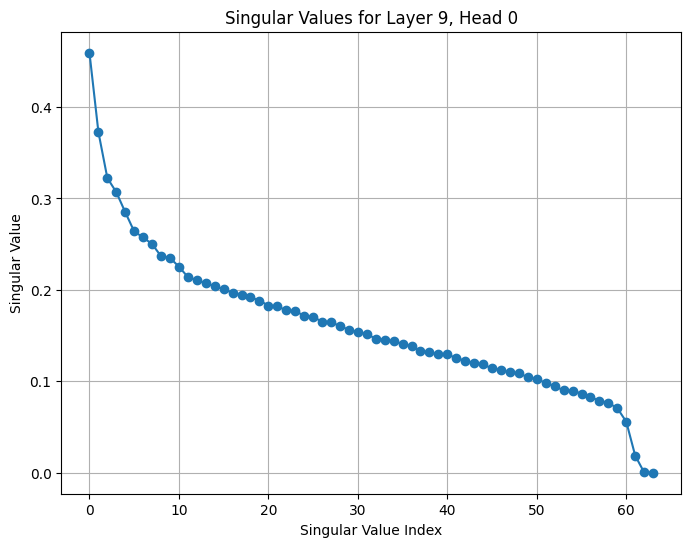

(768, 12, 64)
(1, 12, 768, 64)
(1, 12, 64)


In [ ]:
# Based on Xu Pan's code, compute SVD transform
# SVD transformation: Wq^T Wk = U Sigma V^T
analyzer = HuggingFaceUtils(model)
QK=analyzer.get_QK(model.config.num_attention_heads)

U_total = [] # the vector itself
Vt_total = []
S_total = []
U_head = []
Vt_head = []
S_head = []
layer = 9
(Q, K, plot_path) = QK[layer]
for head in range(model.config.num_attention_heads):
   M = np.zeros((Q.shape[0], Q.shape[0]))
   M[:,:] = np.matmul(Q[:,head,:], K[:,head,:].T) # the interaction matrix
   U, S, Vt, angles = analyzer.svd_angles(M[:,:])
   U_head.append(U) # left singular vectors
   Vt_head.append(Vt) # right singular vectors
   S_head.append(S) # singular values
U_total.append(U_head)
Vt_total.append(Vt_head)
S_total.append(S_head)
embeding_size = Q.shape[2]
U_total = np.array(U_total)[:,:,:,:embeding_size] # because M is low rank, only save up to the rank.
Vt_total = np.array(Vt_total)[:,:,:embeding_size,:]
S_total = np.array(S_total)[:,:,:embeding_size]

# Plot the singular values.
plt.figure(figsize=(8, 6))
plt.plot(S_total[0,0,:], marker='o')
plt.title(f'Singular Values for Layer {layer_index}, Head {head_index}')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
# plt.xlim(0, 64)  # Set x-axis range up to 64
plt.grid(True)
plt.show()

print(Q.shape)
print(U_total.shape)
print(S_total.shape)

U_total shape : (12, 12, 768, 64)
Vt_total shape: (12, 12, 64, 768)
S_total shape : (12, 12, 64)


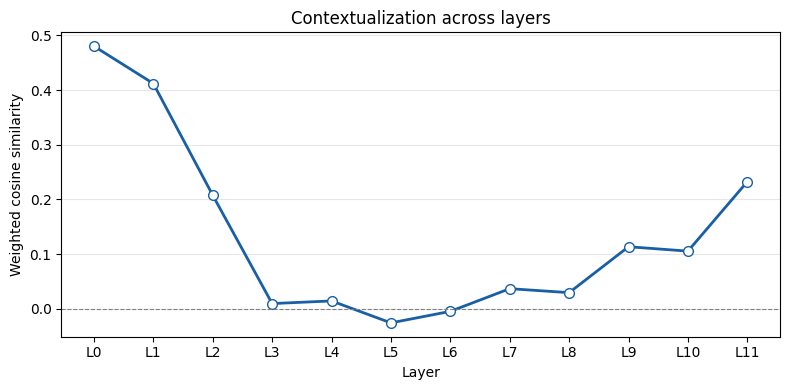

In [ ]:
# Compute SVD for ALL layers

U_total  = []
Vt_total = []
S_total  = []

for layer in range(model.config.num_hidden_layers):
    U_head  = []
    Vt_head = []
    S_head  = []

    (Q, K, plot_path) = QK[layer]

    for head in range(model.config.num_attention_heads):
        M = np.matmul(Q[:, head, :], K[:, head, :].T)
        U, S, Vt, angles = analyzer.svd_angles(M)
        U_head.append(U)
        Vt_head.append(Vt)
        S_head.append(S)

    U_total.append(U_head)
    Vt_total.append(Vt_head)
    S_total.append(S_head)

embeding_size = Q.shape[2]
U_total  = np.array(U_total)[:, :, :, :embeding_size]
Vt_total = np.array(Vt_total)[:, :, :embeding_size, :]
S_total  = np.array(S_total)[:, :, :embeding_size]

num_layers = U_total.shape[0]
num_heads  = U_total.shape[1]

print("U_total shape :", U_total.shape)
print("Vt_total shape:", Vt_total.shape)
print("S_total shape :", S_total.shape)


# Plot 1: Cosine similarity across layers

cos_sim_per_layer = []

for layer in range(num_layers):
    head_cos_sims = []
    for head in range(num_heads):
        U  = U_total[layer, head]
        Vt = Vt_total[layer, head]
        V  = Vt.T
        S  = S_total[layer, head]
        cos = np.sum(U * V, axis=0) / (
              np.linalg.norm(U, axis=0) *
              np.linalg.norm(V, axis=0) + 1e-8)
        weights = S / (S.sum() + 1e-8)
        head_cos_sims.append((weights * cos).sum())
    cos_sim_per_layer.append(np.mean(head_cos_sims))

plt.figure(figsize=(8, 4))
plt.plot(cos_sim_per_layer, marker='o', linewidth=2,
         color='#185FA5', markerfacecolor='white', markersize=7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(range(num_layers), [f'L{i}' for i in range(num_layers)])
plt.xlabel("Layer")
plt.ylabel("Weighted cosine similarity")
plt.title("Contextualization across layers")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()




<div><progress max="1557161267" value="1557168128"></progress> 100.00% [1557168128/1557161267 01:47&lt;00:00]</div>

Found images in /root/.fastai/data/imagenette2/train
Loaded 600 images successfully.


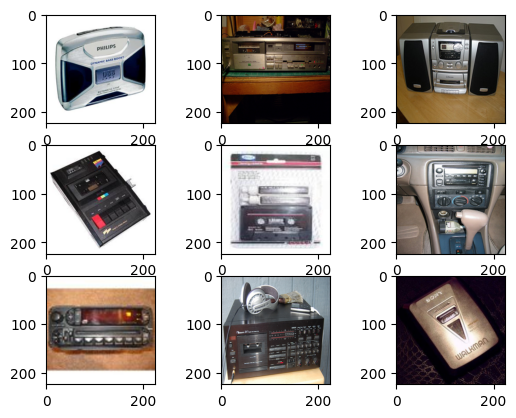

In [ ]:
# Load small image set from Imagenette

# Here we are reading a fixed number of images from each class
import random
from fastai.data.external import untar_data, URLs
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

# Set up the Imagenette dataset.
imagenette_path = untar_data(URLs.IMAGENETTE)
train_dir = Path(imagenette_path) / "train"
print(f"Found images in {train_dir}")

images = []
# num_per_class = 30  # fixed number of images per class
num_per_class = 60    # fixed number of images per class

# Loop over each class directory.
for class_dir in train_dir.iterdir():
    if class_dir.is_dir():
        # Try JPEG then jpg.
        class_image_paths = list(class_dir.rglob("*.JPEG"))
        if len(class_image_paths) == 0:
            class_image_paths = list(class_dir.rglob("*.jpg"))
        # Randomly sample up to num_per_class images from this class.
        selected = random.sample(class_image_paths, min(num_per_class, len(class_image_paths)))
        for img_path in selected:
            try:
                img = Image.open(img_path).convert("RGB")
                images.append(img)
            except UnidentifiedImageError as e:
                print(f"UnidentifiedImageError for {img_path}: {e}")
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

print(f"Loaded {len(images)} images successfully.")

# Preprocess images.
inputs = feature_extractor(images=images, return_tensors="pt")


# Show example images
for i in range(9):
  plt.subplot(3,3,i+1)
  exampleimg = images[i+170].resize((224, 224))
  plt.imshow(exampleimg)


In [ ]:
# based on Xu Pan's code
from transformers import AutoImageProcessor, ViTForImageClassification, CLIPProcessor, CLIPModel, DeiTForImageClassificationWithTeacher, Dinov2Model
import gc

class LayerNormHook(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.outputs = []
        self.hooks = []

        for layer in self.model.vit.encoder.layer:
            hook = layer.layernorm_before.register_forward_hook(self.hook_fn)
            self.hooks.append(hook)

    def hook_fn(self, module, input, output):
        self.outputs.append(output.detach())

    def clear_outputs(self):
        self.outputs = []
        gc.collect()

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def forward(self, input, output_hidden_states=False, output_attentions=False):
        with torch.no_grad():
            output = self.model(input, output_hidden_states=output_hidden_states, output_attentions=output_attentions)
        return output

model_name = "facebook/dino-vitb16"
processor = AutoImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)
model.eval()
hookModel = LayerNormHook(model)

input = processor(images=images, return_tensors="pt")
input = input["pixel_values"].float()
_ = hookModel(input, output_hidden_states=False, output_attentions=False)

output = {'hidden_states': hookModel.outputs}
hookModel.clear_outputs()

start_index = 1 # for Dino (CLS token in position 0; spatial patch tokens start from 1)
head_dim = 64

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/dino-vitb16
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Here we are  computing all the singular left (U) and right (V^T) dimensions for all layers and heads
# Later we will examine the cosine similarity
# Later we will also project the images onto these dimensions
# Xu's code example singular values
analyzer = HuggingFaceUtils(model)
QK=analyzer.get_QK(model.config.num_attention_heads)

U_total_full = [] # the vector itself
Vt_total_full = []
S_total_full = []

for layer in range(model.config.num_hidden_layers):
    (Q, K, plot_path) = QK[layer]

    U_head_full = []
    Vt_head_full = []
    S_head_full = []
    for head in range(model.config.num_attention_heads):
         M = np.zeros((Q.shape[0], Q.shape[0]))
         M[:,:] = np.matmul(Q[:,head,:], K[:,head,:].T) # the interaction matrix
         U, S, Vt, angles = analyzer.svd_angles(M[:,:])
         U_head_full.append(U) # left singular vectors
         Vt_head_full.append(Vt) # right singular vectors
         S_head_full.append(S) # singular values
    U_total_full.append(U_head_full)
    Vt_total_full.append(Vt_head_full)
    S_total_full.append(S_head_full)

embeding_size = Q.shape[2]
U_total_full = np.array(U_total_full)[:,:,:,:embeding_size] # because M is low rank, only save up to the rank.
Vt_total_full = np.array(Vt_total_full)[:,:,:embeding_size,:]
S_total_full = np.array(S_total_full)[:,:,:embeding_size]
print(U_total_full.shape) # first indice is layer; second is head

In [ ]:
print(U_total_full.shape)
print(Vt_total_full.shape)
print(Vt_total_full[9, 2].T.shape)
print(U_total_full[9, 2].shape)
myU=U_total_full[8, 5]
myV=Vt_total_full[8, 5].T
print(myV[:,0].shape)
for i in range(10):
  print(np.dot(myU[:,i],myV[:,i]))

In [ ]:
# SVD cosine similarity plots
# average cosine similarity between U and V on the Y axis as a function of layer on the X axis (for each layer averaged across the heads).
# And then a weighted cosine similarity as a function of layer (with weights corresponding to the singular value)
# Cosine similarity is the dot product since vectors are orthonormal
# The weighted cosine similarity per head is computed by taking the singular value as a weight for each cosine
# similarity and normalizing by the sum of singular values.

# Lists to store the average metrics per layer.
layer_avg_cosines = []
layer_weighted_cosines = []
num_layers = model.config.num_hidden_layers

for layer in range(model.config.num_hidden_layers):
    (Q, K, plot_path) = QK[layer]
    head_cos_sim_list = []
    head_weighted_cos_sim_list = []
    for head in range(model.config.num_attention_heads):
         # if precomputed, as in code above
         U = U_total_full[layer, head]
         V = Vt_total_full[layer, head]
         V = V.T
         S = S_total_full[layer, head]
         # if not precomputed, then we could do so from scratch
         #M = np.zeros((Q.shape[0], Q.shape[0]))
         #M[:,:] = np.matmul(Q[:,head,:], K[:,head,:].T) # the interaction matrix
         #U, S, Vt, angles = analyzer.svd_angles(M[:,:])
         #V = Vt.T  # Convert Vt to V so that corresponding singular vectors can be compared.
         #embeding_size = Q.shape[2]
         #U = np.array(U)[:,:embeding_size]
         #V = np.array(V)[:,:embeding_size]
         #S = np.array(S)[:embeding_size]

         # cosine similarity is the dot product
         cos_similarities = np.array([np.dot(U[:, i], V[:, i]) for i in range(len(S))])
         # Average cosine similarity for the current head.
         #avg_cos = np.mean(cos_similarities)
         avg_cos = np.sum(cos_similarities)/len(S)
         # Weighted cosine similarity for the current head: weight by the singular values.
         weighted_cos = np.sum(S * cos_similarities) / np.sum(S)

         head_cos_sim_list.append(avg_cos)
         head_weighted_cos_sim_list.append(weighted_cos)

    # Average over heads for this layer.
    layer_avg_cosines.append(np.mean(head_cos_sim_list))
    layer_weighted_cosines.append(np.mean(head_weighted_cos_sim_list))




In [ ]:
# Weighted Cosine Similarity plot per layer (compare to Xu's Neurips paper)
# Convert layer indices to an array for plotting.
layers = np.arange(num_layers)
plt.figure(figsize=(8, 6))
plt.plot(layers, layer_weighted_cosines, marker='o', color='red')
plt.xlabel('Layer Index')
plt.ylabel('Weighted Cosine Similarity (U, V)')
plt.title('Weighted Cosine Similarity between U and V per Layer')
plt.grid(True)
plt.show()


In [ ]:
# Average Cosine Similarity plot per layer, not weighted by the singular value
plt.figure(figsize=(8, 6))
plt.plot(layers, layer_avg_cosines, marker='o', color='red')
plt.xlabel('Layer Index')
plt.ylabel('Average Cosine Similarity (U, V)')
plt.title('Average Cosine Similarity between U and V per Layer')
plt.grid(True)
plt.show()


In [ ]:
# Compute average cosine similarity; Xu's direct code

Ut_total_full=np.transpose(U_total_full, [0,1,3,2])

cosine_similarity = np.einsum('...i,...i', Ut_total_full, Vt_total_full)
cosine_similarity = np.mean(cosine_similarity, axis = 2)
cosine_similarity = np.mean(cosine_similarity, axis = 1)
plt.figure(figsize=(8, 6))
plt.plot(layers, cosine_similarity, marker="o", color="r", label=model_name.split('/')[1])
plt.xlabel('Layer Index')
plt.ylabel('Average Cosine Similarity (U, V)')
plt.title('Average Cosine Similarity between U and V per Layer')
plt.grid(True)
plt.show()



In [ ]:
def plot_top_images_SVD_new_layers(layer_index, head_index, top_n=5):
    """
    For a given transformer layer (for plotting) and head, this function:
      - Hooks the layer's pre-attention layernorm to capture hidden states.
      - Runs a forward pass to obtain pre-attention embeddings.
      - Extracts the SVD components for the given head from U_total and Vt_total.
        (Assumes U_total and Vt_total have shape (12, 12, 768, 64), so we use U_total[layer_index, head_index])
      - Projects all patch tokens (excluding the CLS token).
      - Reshapes the projected tokens into spatial maps.
      - For each SVD channel, computes a product metric and selects the top images.
      - Plots, for each channel, the original image and an overlay (U in red and V in cyan).
    """
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image

    global model, inputs, images, U_total_full, Vt_total_full

    # Hook the chosen layer's pre-attention layernorm.
    vit_layer = model.vit.encoder.layer[layer_index]  # note naming convention in Xu's paper starts from layer 0
    activations = {}
    def hook_fn(module, input, output):
        activations["pre_attn"] = output.detach()
    hook_handle = vit_layer.layernorm_before.register_forward_hook(hook_fn)

    # Run the forward pass.
    _ = model(**inputs, output_hidden_states=True)
    hook_handle.remove()

    # Get pre-attention embeddings.
    pre_attn_embeddings = activations["pre_attn"]
    batch_size, seq_len, hidden_size = pre_attn_embeddings.shape
    num_patches = seq_len - 1  # drop the CLS token.
    spatial_size = int(np.sqrt(num_patches))
    print(f"Pre-attention embeddings shape: {pre_attn_embeddings.shape}")
    print(f"Batch size: {batch_size}, seq_len: {seq_len}, num_patches: {num_patches}, spatial_size: {spatial_size}")

    # Get the projection matrices for the given head.
    device = pre_attn_embeddings.device
    tokens_dtype = pre_attn_embeddings.dtype
    U_comp = torch.tensor(U_total_full[layer_index, head_index], device=device, dtype=tokens_dtype)  # shape (768, 64)
    V_comp = torch.tensor(Vt_total_full[layer_index, head_index].T, device=device, dtype=tokens_dtype)  # shape (768, 64)

    # Project tokens onto the SVD components.
    tokens = pre_attn_embeddings[:, 1:, :]
    print(f"Tokens shape (excluding CLS): {tokens.shape}")
    U_proj = tokens.matmul(U_comp)  # shape (batch, num_patches, 64)
    V_proj = tokens.matmul(V_comp)  # shape (batch, num_patches, 64)
    print(f"U_proj shape: {U_proj.shape}, V_proj shape: {V_proj.shape}")

    # Convert projections to numpy and reshape into spatial maps.
    U_proj_np = U_proj.cpu().numpy()
    V_proj_np = V_proj.cpu().numpy()
    try:
        U_maps_all = U_proj_np.reshape(batch_size, spatial_size, spatial_size, 64).transpose(0, 3, 1, 2)
        V_maps_all = V_proj_np.reshape(batch_size, spatial_size, spatial_size, 64).transpose(0, 3, 1, 2)
    except Exception as e:
        print("Error during reshaping:", e)
        return
    print(f"U_maps_all shape: {U_maps_all.shape}, V_maps_all shape: {V_maps_all.shape}")

    # For each SVD channel, compute product metric and plot top images.
    n_channels = U_maps_all.shape[1]  # should be 64.
    fig, axes = plt.subplots(n_channels, top_n * 2, figsize=(top_n * 2.5, n_channels * 1.5))
    if n_channels == 1:
        axes = np.expand_dims(axes, 0)

    for ch in range(n_channels):
        # metric: (max over spatial dimensions of U_maps_all) * (max over spatial dimensions of V_maps_all)
        # because we want to choose images with large projections onto both the query and the key feature
        max_U = np.max(U_maps_all[:, ch, :, :], axis=(1, 2))
        max_V = np.max(V_maps_all[:, ch, :, :], axis=(1, 2))
        metrics = max_U * max_V

        top_indices = np.argsort(metrics)[-top_n:][::-1]
        for j, img_idx in enumerate(top_indices):
            # Plot the original image.
            orig_img = images[img_idx].resize((224, 224))
            ax_orig = axes[ch, j * 2]
            ax_orig.imshow(orig_img)
            ax_orig.axis("off")
            if j == 0:
                ax_orig.set_ylabel(f"Ch {ch}", rotation=0, labelpad=40, fontsize=6)

            # Create an overlay image from U and V maps (red for U, cyan for V).
            U_map = U_maps_all[img_idx, ch]
            V_map = V_maps_all[img_idx, ch]
            # Normalize U_map.
            U_min, U_max = np.percentile(U_map, 30), np.percentile(U_map, 95)
            U_norm = np.clip((U_map - U_min) / (U_max - U_min + 1e-8), 0, 1)
            # Normalize V_map.
            V_min, V_max = np.percentile(V_map, 30), np.percentile(V_map, 95)
            V_norm = np.clip((V_map - V_min) / (V_max - V_min + 1e-8), 0, 1)
            # Stack channels to create red (U) and cyan (V gives both green and blue).
            overlay = np.stack([U_norm, V_norm, V_norm], axis=-1)
            overlay_resized = np.array(
                Image.fromarray((overlay * 255).astype(np.uint8)).resize((224, 224))
            ) / 255.0
            orig_arr = np.array(orig_img).astype(np.float32) / 255.0
            overlay_img = np.clip(overlay_resized * 0.6 + orig_arr * 0.4, 0, 1)
            ax_overlay = axes[ch, j * 2 + 1]
            ax_overlay.imshow(overlay_img)
            ax_overlay.axis("off")

    fig.subplots_adjust(hspace=0.01)
    plt.show()

In [ ]:
def plot_top_images_SVD_new_layers_negative(layer_index, head_index, top_n=5):
    """
    For a given transformer layer (for plotting) and head, this function:
      - Hooks the layer's pre-attention layernorm to capture hidden states.
      - Runs a forward pass to obtain pre-attention embeddings.
      - Extracts the SVD components for the given head from U_total and Vt_total.
        (Assumes U_total and Vt_total have shape (1, 12, 768, 64), so we use U_total[layer_index, head_index])
      - Projects all patch tokens (excluding the CLS token) in a vectorized manner.
      - Reshapes the projected tokens into spatial maps.
      - For each SVD channel, computes a product metric and selects the top images.
      - Plots, for each channel, the original image and an overlay (U in red and V in cyan).
      - Negative for U_total_full= -U_total_full and Vt_total_full= -Vt_total_full, since also valid SVD
    """
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image

    global model, inputs, images, U_total_full, Vt_total_full

    # since the negatives are also a valid SVD solution
    U_total_full_neg = -U_total_full
    Vt_total_full_neg = -Vt_total_full

    # Hook the chosen layer's pre-attention layernorm.
    vit_layer = model.vit.encoder.layer[layer_index]  # note naming convention in Xu's paper starts from layer 0
    activations = {}
    def hook_fn(module, input, output):
        activations["pre_attn"] = output.detach()
    hook_handle = vit_layer.layernorm_before.register_forward_hook(hook_fn)

    # Run the forward pass.
    _ = model(**inputs, output_hidden_states=True)
    hook_handle.remove()

    # Get pre-attention embeddings.
    pre_attn_embeddings = activations["pre_attn"]
    batch_size, seq_len, hidden_size = pre_attn_embeddings.shape
    num_patches = seq_len - 1  # drop the CLS token.
    spatial_size = int(np.sqrt(num_patches))
    print(f"Pre-attention embeddings shape: {pre_attn_embeddings.shape}")
    print(f"Batch size: {batch_size}, seq_len: {seq_len}, num_patches: {num_patches}, spatial_size: {spatial_size}")

    # Get the projection matrices for the given head.
    device = pre_attn_embeddings.device
    tokens_dtype = pre_attn_embeddings.dtype
    U_comp = torch.tensor(U_total_full_neg[layer_index, head_index], device=device, dtype=tokens_dtype)  # shape (768, 64)
    V_comp = torch.tensor(Vt_total_full_neg[layer_index, head_index].T, device=device, dtype=tokens_dtype)  # shape (768, 64)

    # Project tokens onto the SVD components.
    tokens = pre_attn_embeddings[:, 1:, :]
    print(f"Tokens shape (excluding CLS): {tokens.shape}")
    U_proj = tokens.matmul(U_comp)  # shape (batch, num_patches, 64)
    V_proj = tokens.matmul(V_comp)  # shape (batch, num_patches, 64)
    print(f"U_proj shape: {U_proj.shape}, V_proj shape: {V_proj.shape}")

    # Convert projections to numpy and reshape into spatial maps.
    U_proj_np = U_proj.cpu().numpy()
    V_proj_np = V_proj.cpu().numpy()
    try:
        U_maps_all = U_proj_np.reshape(batch_size, spatial_size, spatial_size, 64).transpose(0, 3, 1, 2)
        V_maps_all = V_proj_np.reshape(batch_size, spatial_size, spatial_size, 64).transpose(0, 3, 1, 2)
    except Exception as e:
        print("Error during reshaping:", e)
        return
    print(f"U_maps_all shape: {U_maps_all.shape}, V_maps_all shape: {V_maps_all.shape}")

    # For each SVD channel, compute product metric and plot top images.
    n_channels = U_maps_all.shape[1]  # should be 64.
    fig, axes = plt.subplots(n_channels, top_n * 2, figsize=(top_n * 2.5, n_channels * 1.5))
    if n_channels == 1:
        axes = np.expand_dims(axes, 0)

    for ch in range(n_channels):

        # metric: (max over spatial dimensions of U_maps_all) * (max over spatial dimensions of V_maps_all)
        # because we want to choose images with large projections onto both the query and the key feature
        max_U = np.max(U_maps_all[:, ch, :, :], axis=(1, 2))
        max_V = np.max(V_maps_all[:, ch, :, :], axis=(1, 2))
        metrics = max_U * max_V

        top_indices = np.argsort(metrics)[-top_n:][::-1]
        for j, img_idx in enumerate(top_indices):
            # Plot the original image.
            orig_img = images[img_idx].resize((224, 224))
            ax_orig = axes[ch, j * 2]
            ax_orig.imshow(orig_img)
            ax_orig.axis("off")
            if j == 0:
                ax_orig.set_ylabel(f"Ch {ch}", rotation=0, labelpad=40, fontsize=6)

            # Create an overlay image from U and V maps (red for U, cyan for V).
            U_map = U_maps_all[img_idx, ch]
            V_map = V_maps_all[img_idx, ch]
            # Normalize U_map.
            U_min, U_max = np.percentile(U_map, 30), np.percentile(U_map, 95)
            U_norm = np.clip((U_map - U_min) / (U_max - U_min + 1e-8), 0, 1)
            # Normalize V_map.
            V_min, V_max = np.percentile(V_map, 30), np.percentile(V_map, 95)
            V_norm = np.clip((V_map - V_min) / (V_max - V_min + 1e-8), 0, 1)
            # Stack channels to create red (U) and cyan (V gives both green and blue).
            overlay = np.stack([U_norm, V_norm, V_norm], axis=-1)
            overlay_resized = np.array(
                Image.fromarray((overlay * 255).astype(np.uint8)).resize((224, 224))
            ) / 255.0
            orig_arr = np.array(orig_img).astype(np.float32) / 255.0
            overlay_img = np.clip(overlay_resized * 0.6 + orig_arr * 0.4, 0, 1)
            ax_overlay = axes[ch, j * 2 + 1]
            ax_overlay.imshow(overlay_img)
            ax_overlay.axis("off")

    fig.subplots_adjust(hspace=0.01)
    plt.show()

In [ ]:
plot_top_images_SVD_new_layers_negative(layer_index=9, head_index=2, top_n=6)

In [ ]:
plot_top_images_SVD_new_layers(layer_index=9, head_index=2, top_n=6)

In [ ]:
plot_top_images_SVD_new_layers(layer_index=8, head_index=9, top_n=6)

In [ ]:
plot_top_images_SVD_new_layers_negative(layer_index=8, head_index=9, top_n=6)